In [3]:
import torch
from transformers import AutoTokenizer, AutoModel
path = "OpenGVLab/InternVL3-9B"
model = AutoModel.from_pretrained(
    path,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    use_flash_attn=True,
    trust_remote_code=True).eval().cuda()


A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL3-9B:
- conversation.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL3-9B:
- modeling_internlm2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL3-9B:
- modeling_intern_vit.py
- conversation.py
- modeling_internlm2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/home/cqilab/anaconda3/envs/llmfinetune/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing 

In [3]:
!nvidia-smi

Tue Apr 15 10:50:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:67:00.0 Off |                  N/A |
|  0%   26C    P8             24W /  350W |   22724MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

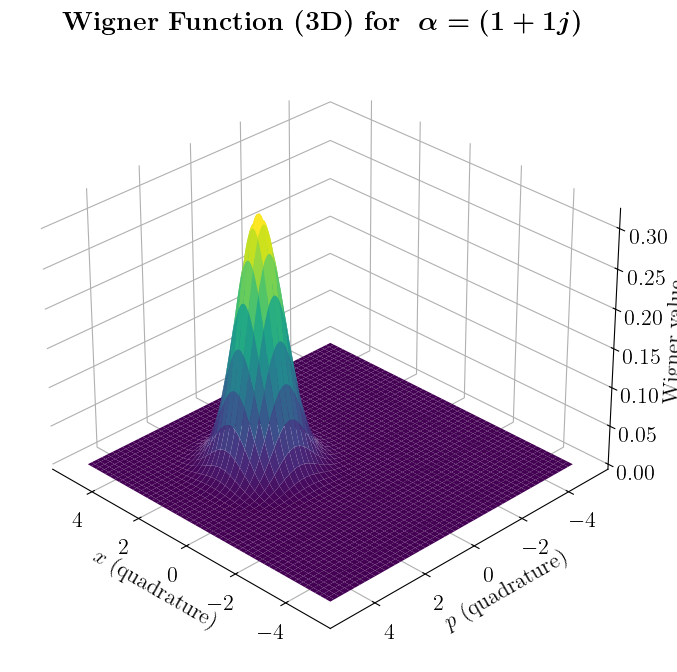

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from qutip import basis, displace, wigner

# LaTeX font settings
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# Parameters
alpha = 1 + 1j
N = 30
xvec = np.linspace(-5, 5, 200)

# Coherent state
vacuum = basis(N, 0)
state = displace(N, alpha) * vacuum

# Compute Wigner function
W = wigner(state, xvec, xvec)
X, Y = np.meshgrid(xvec, xvec)

# 3D Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot surface with smooth shading and transparency background
surface = ax.plot_surface(X, Y, W, cmap='viridis', edgecolor='none', antialiased=True)

# Make background transparent
ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# Labels (LaTeX)
ax.set_title(r"\textbf{Wigner Function (3D) for } $\boldsymbol{\alpha = %s}$" % alpha)
ax.set_xlabel(r"$x$ (quadrature)")
ax.set_ylabel(r"$p$ (quadrature)")
ax.set_zlabel(r"Wigner value")
ax.view_init(elev=30, azim=135)

# Save with transparent background
plt.savefig("wigner_3d_alpha_clean.png", dpi=300, transparent=True)
plt.tight_layout()
plt.show()
